# Analyse exploratoire (EDA) de la table Vehicle

Données : STATS19 du Department for Transport (Grande-Bretagne), véhicules impliqués dans des collisions corporelles 2021-2025.
Objectif de ce notebook : comprendre le contenu de la table avant tout nettoyage, repérer les problèmes de qualité, et justifier les choix faits ensuite dans `clean_vehicle.py`.

**Particularité de cette table** : elle ne contient pas la gravité (`collision_severity`), qui est dans la table Collision. Les sections 6 à 11 qui parlent de gravité utilisent donc une jointure sur `collision_index` avec la table Collision (si elle est placée dans `data_brut/`). Sans elle, ces cellules s'arrêtent proprement avec un message.

## Plan
1. Chargement et structure
2. Identifiant et doublons
3. Valeurs manquantes (codées -1, 9, 99)
4. Rupture de schéma 2024-2025
5. Valeurs extrêmes
6. La cible : la gravité (via jointure avec Collision)
7. Biais : conducteurs non identifiés et changement de saisie
8. Analyse temporelle
9. Gravité selon les caractéristiques du véhicule et du conducteur
10. Profil socio-géographique du conducteur
11. Liens avec la gravité (V de Cramér)
12. Synthèse : constats → décisions de nettoyage

## 1. Chargement et structure

In [1]:
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60, "display.width", 200)

def find_file(pattern):
    """Cherche un fichier .zip/.csv dans data_brut (ou ../data_brut)."""
    for base in [Path("data_brut"), Path("../data_brut")]:
        files = sorted(p for p in base.glob(pattern) if p.suffix.lower() in (".zip", ".csv"))
        if files:
            return files[0]
    return None

def read_raw(path, **kw):
    if path.suffix.lower() == ".zip":
        with zipfile.ZipFile(path) as z:
            name = [n for n in z.namelist()
                    if n.lower().endswith(".csv") and not n.startswith("__MACOSX")][0]
            with z.open(name) as f:
                return pd.read_csv(f, low_memory=False, **kw)
    return pd.read_csv(path, low_memory=False, **kw)

DATA_PATH = find_file("*vehicle*")
if DATA_PATH is None:
    raise FileNotFoundError("Placez le fichier Vehicle brut dans le dossier data_brut/")
print("Fichier utilisé :", DATA_PATH)

df = read_raw(DATA_PATH)
print(f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.head(3)

Fichier utilisé : data_brut/dft-road-casualty-statistics-vehicle-last-5-years_csv.zip


937,265 lignes x 32 colonnes


,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane_historic,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver_historic,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2021622100736,2021,622100736,1,9,0,18,19,2,6,0,0,1,0,0,0,0,4,1,6,6,1,35,6,1998,2,10,CHEVROLET CRUZE,4,W01000966,0,-1
1,2021010319369,2021,010319369,1,9,9,99,99,9,9,99,99,9,9,99,9,99,9,9,6,6,1,25,5,1598,1,9,CHEVROLET CRUZE,2,E01002078,0,-1
2,2021122100703,2021,122100703,2,9,0,2,2,0,0,0,0,2,0,0,0,0,2,1,6,6,1,50,8,1796,1,11,CHEVROLET CRUZE,7,E01027646,0,-1


In [2]:
# Résumé de chaque colonne : type, nombre de valeurs distinctes, exemple
summary = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_distinctes": df.nunique(),
    "NaN": df.isna().sum(),
    "exemple": df.iloc[0],
})
summary

,type,valeurs_distinctes,NaN,exemple
collision_index,str,513801,0,2021622100736
collision_year,int64,5,0,2021
collision_ref_no,str,510837,0,622100736
vehicle_reference,int64,45,0,1
vehicle_type,int64,23,0,9
towing_and_articulation,int64,8,0,0
vehicle_manoeuvre_historic,int64,20,0,18
vehicle_manoeuvre,int64,19,0,19
vehicle_direction_from,int64,11,0,2
vehicle_direction_to,int64,11,0,6


**Lecture :** **32 colonnes** (contre 44 pour Collision), presque toutes des codes numériques (catégories). Aucune cellule n'est un vrai NaN : les manquants sont cachés dans des codes (`-1`, `9`, `99`). Seules 4 colonnes sont du texte : `collision_index`, `collision_ref_no`, `generic_make_model` et `lsoa_of_driver`. La table compte **937 265 lignes (une par véhicule)** pour **513 801 collisions distinctes**, soit exactement le nombre de lignes de la table Collision : chaque collision a au moins un véhicule. La table ne contient **pas** la gravité.

## 2. Identifiant et doublons

In [3]:
key = ["collision_index", "vehicle_reference"]
print("collision_index seul unique           :", df["collision_index"].is_unique)
print("(collision_index, vehicle_reference) unique :", not df.duplicated(key).any())
print("Collisions distinctes                 :", df["collision_index"].nunique())
print("Lignes dupliquées (toutes colonnes)   :", df.duplicated().sum())

# collision_ref_no est réutilisé d'une année à l'autre (comme dans la table Collision)
n_idx_par_ref = df.groupby("collision_ref_no")["collision_index"].nunique()
print(f"collision_ref_no partagés par plusieurs collisions : {(n_idx_par_ref > 1).sum():,}")

# Nombre de véhicules par collision
veh_par_coll = df.groupby("collision_index").size()
print()
print(veh_par_coll.describe().round(2))

# vehicle_reference devrait aller de 1 à n (n = nb de véhicules de la collision)
n_veh = df.groupby("collision_index")["vehicle_reference"].transform("size")
incoh = df[df["vehicle_reference"] > n_veh]
print(f"\nvehicle_reference > nb de lignes de la collision : {len(incoh):,} lignes")
print("Valeurs les plus hautes de vehicle_reference :", sorted(df["vehicle_reference"].unique())[-8:])

collision_index seul unique           : False


(collision_index, vehicle_reference) unique : True
Collisions distinctes                 : 513801


Lignes dupliquées (toutes colonnes)   : 0


collision_ref_no partagés par plusieurs collisions : 1,744



count    513801.00
mean          1.82
std           0.69
min           1.00
25%           1.00
50%           2.00
75%           2.00
max          26.00
dtype: float64



vehicle_reference > nb de lignes de la collision : 577 lignes
Valeurs les plus hautes de vehicle_reference : [np.int64(162), np.int64(203), np.int64(227), np.int64(275), np.int64(291), np.int64(612), np.int64(964), np.int64(992)]


**Lecture :** `collision_index` n'est plus unique ici (une ligne par véhicule). La bonne clé est le couple **(`collision_index`, `vehicle_reference`)** : 0 doublon. Une collision a en moyenne 1,82 véhicule (maximum 26), identique à `number_of_vehicles` de la table Collision. `collision_ref_no` est réutilisé par plusieurs collisions (1 744 cas) : comme pour Collision, il ne faut jamais l'utiliser pour joindre. **Piège :** `vehicle_reference` n'est pas toujours numéroté de 1 à n : 577 lignes ont un numéro supérieur au nombre de véhicules de leur collision, avec des valeurs allant jusqu'à 992. On s'en sert comme identifiant, jamais comme un nombre de véhicules.

## 3. Valeurs manquantes (codées -1, 9, 99)

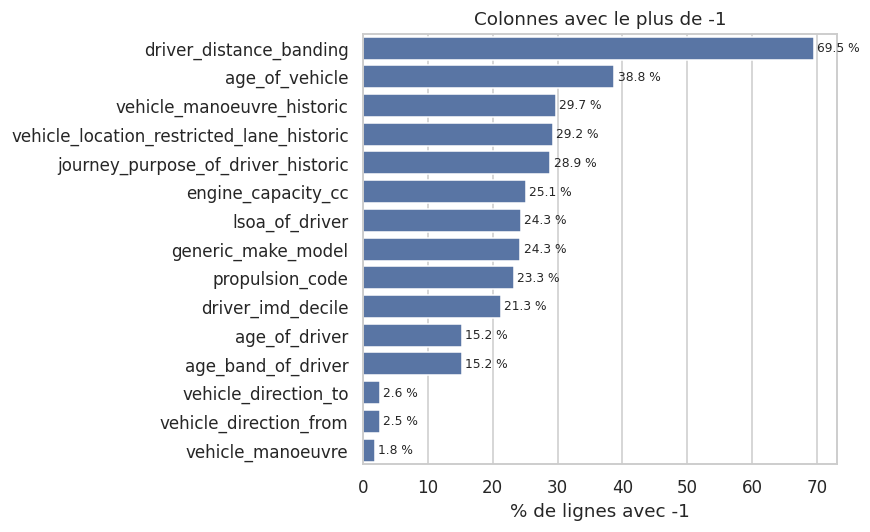

In [4]:
def pct_minus1(s):
    """Part de valeurs -1 (ou '-1' pour les colonnes texte)."""
    if pd.api.types.is_numeric_dtype(s):
        return (s == -1).mean() * 100
    return s.astype(str).eq("-1").mean() * 100

miss = df.apply(pct_minus1).sort_values(ascending=False)
top = miss[miss > 0].head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top.values, y=top.index, color="#4C72B0", ax=ax)
ax.set_xlabel("% de lignes avec -1"); ax.set_ylabel("")
ax.set_title("Colonnes avec le plus de -1")
for i, v in enumerate(top.values):
    ax.text(v + 0.5, i, f"{v:.1f} %", va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [5]:
# 9 et 99 : "inconnu" dans certaines colonnes, mais de vraies valeurs ailleurs
# (à confirmer avec le guide DfT : road-safety-open-data-guide)
rows = []
for col in df.columns:
    if col in ("collision_index", "collision_ref_no", "lsoa_of_driver", "generic_make_model",
               "collision_year", "vehicle_reference", "age_of_driver", "engine_capacity_cc", "age_of_vehicle"):
        continue
    for code_ in (9, 99):
        n = (df[col] == code_).sum()
        if n > 0:
            rows.append((col, code_, n, n / len(df) * 100))
codes = pd.DataFrame(rows, columns=["colonne", "code", "lignes", "%"]).sort_values("%", ascending=False)
# Colonnes où le code 9 est une VRAIE valeur (voiture, virage, tranche d'âge, décile...) -> pas un manquant
REAL_9 = {"vehicle_type", "vehicle_manoeuvre", "vehicle_manoeuvre_historic", "age_band_of_driver",
          "driver_imd_decile", "vehicle_location_restricted_lane", "vehicle_location_restricted_lane_historic",
          "hit_object_in_carriageway", "hit_object_off_carriageway"}
codes["interprétation"] = np.where((codes["code"] == 9) & codes["colonne"].isin(REAL_9),
                                   "valeur réelle", "inconnu (à confirmer, guide DfT)")
display(codes.round(1).head(25).reset_index(drop=True))

print()
print("vehicle_type = 9 :", f"{(df['vehicle_type'] == 9).sum():,}", f"lignes ({(df['vehicle_type'] == 9).mean()*100:.1f} %) -> c'est la VOITURE, PAS un manquant")
print("vehicle_manoeuvre = 9 :", f"{(df['vehicle_manoeuvre'] == 9).sum():,}", "lignes -> c'est une vraie manoeuvre (virage), PAS un manquant")
print("vehicle_type = 99 :", (df["vehicle_type"] == 99).sum(), "lignes -> inconnu (déclaré par la personne)")

,colonne,code,lignes,%,interprétation
0,vehicle_type,9,637681,68.0,valeur réelle
1,age_band_of_driver,9,94930,10.1,valeur réelle
2,vehicle_manoeuvre,9,80521,8.6,valeur réelle
3,vehicle_direction_to,9,76750,8.2,"inconnu (à confirmer, guide DfT)"
4,vehicle_direction_from,9,76750,8.2,"inconnu (à confirmer, guide DfT)"
5,skidding_and_overturning,9,76624,8.2,"inconnu (à confirmer, guide DfT)"
6,hit_object_in_carriageway,99,76401,8.2,"inconnu (à confirmer, guide DfT)"
7,vehicle_leaving_carriageway,9,75031,8.0,"inconnu (à confirmer, guide DfT)"
8,vehicle_location_restricted_lane,99,74959,8.0,"inconnu (à confirmer, guide DfT)"
9,vehicle_manoeuvre,99,74901,8.0,"inconnu (à confirmer, guide DfT)"



vehicle_type = 9 : 637,681 lignes (68.0 %) -> c'est la VOITURE, PAS un manquant
vehicle_manoeuvre = 9 : 80,521 lignes -> c'est une vraie manoeuvre (virage), PAS un manquant
vehicle_type = 99 : 617 lignes -> inconnu (déclaré par la personne)


**Lecture :** - Colonnes les plus touchées par `-1` : `driver_distance_banding` (69,5 %), `age_of_vehicle` (38,8 %), les colonnes `*_historic` (~29 %), `engine_capacity_cc` (25,1 %), `generic_make_model` et `lsoa_of_driver` (24,3 %), `propulsion_code` (23,3 %), `driver_imd_decile` (21,3 %) et `age_of_driver` (15,2 %).
- **Piège principal :** `9` n'est pas un manquant dans plusieurs colonnes. `vehicle_type = 9` est la **voiture** (68 % des lignes), `vehicle_manoeuvre = 9` est une vraie manoeuvre, et `9` est aussi une tranche d'âge et un décile. Le nettoyage doit se faire **colonne par colonne**. Dans les autres colonnes (direction, dérapage, objet heurté...), `9`/`99` sont des « inconnus » à ~8 %, à confirmer avec le guide DfT.
- Certains `-1` sont des **non applicables**, pas des manquants : tous les vélos (81 486 lignes) ont `propulsion_code = -1` et `age_of_vehicle = -1`, et 99 % des véhicules électriques (`propulsion_code = 3`) ont `engine_capacity_cc = -1`.
- `driver_imd_decile = -1` (21,3 %) tombe sur les mêmes lignes que `lsoa_of_driver = -1` (24,3 %) : le décile est dérivé du LSOA.

## 4. Rupture de schéma 2024-2025

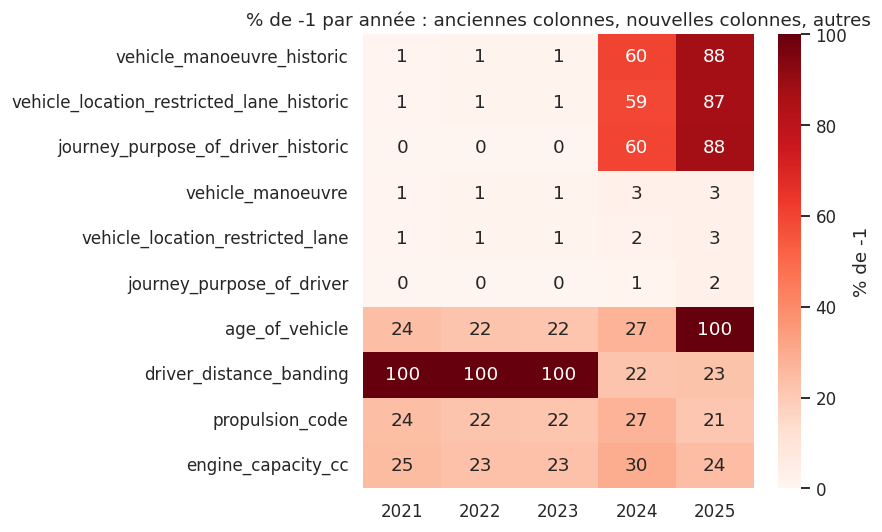

In [6]:
cols_hist = ["vehicle_manoeuvre_historic", "vehicle_location_restricted_lane_historic",
             "journey_purpose_of_driver_historic"]
cols_new = ["vehicle_manoeuvre", "vehicle_location_restricted_lane", "journey_purpose_of_driver"]
cols_other = ["age_of_vehicle", "driver_distance_banding", "propulsion_code", "engine_capacity_cc"]

heat = pd.DataFrame({c: df.groupby("collision_year")[c].apply(pct_minus1)
                     for c in cols_hist + cols_new + cols_other}).T

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% de -1"}, ax=ax)
ax.set_title("% de -1 par année : anciennes colonnes, nouvelles colonnes, autres")
ax.set_xlabel("")
plt.tight_layout(); plt.show()

In [7]:
# Les nouvelles colonnes sont-elles complètes sur toute la période ? (vérification clé)
pd.crosstab(df["vehicle_manoeuvre"], df["collision_year"])

collision_year,2021,2022,2023,2024,2025
vehicle_manoeuvre,,,,,
-1,1339,2320,2415,5582,5198
1,2448,2438,2305,2314,2217
2,8093,8676,8136,8000,8143
3,7654,7856,7609,7350,7295
4,10714,10671,10503,9925,9590
5,8521,8842,9062,8828,8818
6,1289,1280,1236,1168,1207
7,6085,6233,6053,5776,6038
8,843,809,792,786,856


In [8]:
# Les codes des anciennes et nouvelles colonnes sont-ils les mêmes ? (ex. manoeuvre)
print("Valeurs de vehicle_manoeuvre_historic :", sorted(df["vehicle_manoeuvre_historic"].unique()))
print("Valeurs de vehicle_manoeuvre          :", sorted(df["vehicle_manoeuvre"].unique()))
print()
print("age_of_vehicle : % de -1 en 2025 =", round(pct_minus1(df.loc[df.collision_year == 2025, "age_of_vehicle"]), 1))
print("driver_distance_banding : % de -1 avant 2024 =",
      round(pct_minus1(df.loc[df.collision_year < 2024, "driver_distance_banding"]), 1))

Valeurs de vehicle_manoeuvre_historic : [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(99)]
Valeurs de vehicle_manoeuvre          : [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(19), np.int64(20), np.int64(99)]

age_of_vehicle : % de -1 en 2025 = 100.0
driver_distance_banding : % de -1 avant 2024 = 100.0


**Lecture :** - Les anciennes colonnes (`vehicle_manoeuvre_historic`, `vehicle_location_restricted_lane_historic`, `journey_purpose_of_driver_historic`) s'effondrent : environ 1 % de `-1` jusqu'en 2023, puis ~60 % en 2024 et ~87-88 % en 2025.
- Les nouvelles colonnes sont renseignées sur les 5 ans (`-1` ≤ 3 %), avec des codes différents (le code `18` de l'ancienne manoeuvre devient `19`, et `20` n'apparaît qu'à partir de 2024). Il n'y a donc pas besoin de table de correspondance : on supprime les anciennes colonnes.
- **Deux ruptures supplémentaires, propres à cette table :** `age_of_vehicle` est à **100 % de `-1` en 2025** (alors qu'il est à 22-28 % les autres années), et `driver_distance_banding` est à **100 % de `-1` avant 2024** (variable créée en 2024). Utiliser ces colonnes telles quelles introduirait un biais lié à l'année.

## 5. Valeurs extrêmes

       age_of_driver  engine_capacity_cc  age_of_vehicle
count       795025.0            702276.0        573978.0
mean            41.2              1786.0             8.6
std             16.9              1579.1             5.9
min              1.0                 1.0             0.0
50%             39.0              1560.0             8.0
90%             65.0              2299.0            16.0
99%             84.0             12000.0            23.0
99.9%           92.0             12902.0            41.0
max            105.0             48000.0           123.0

Conducteurs de moins de 17 ans       : 13962
Conducteurs de plus de 100 ans       : 4
Cylindrée > 8 000 cc                 : 11444
Cylindrée entre 1 et 49 cc           : 1639
Véhicules de plus de 30 ans          : 1525
Véhicules de plus de 50 ans          : 262


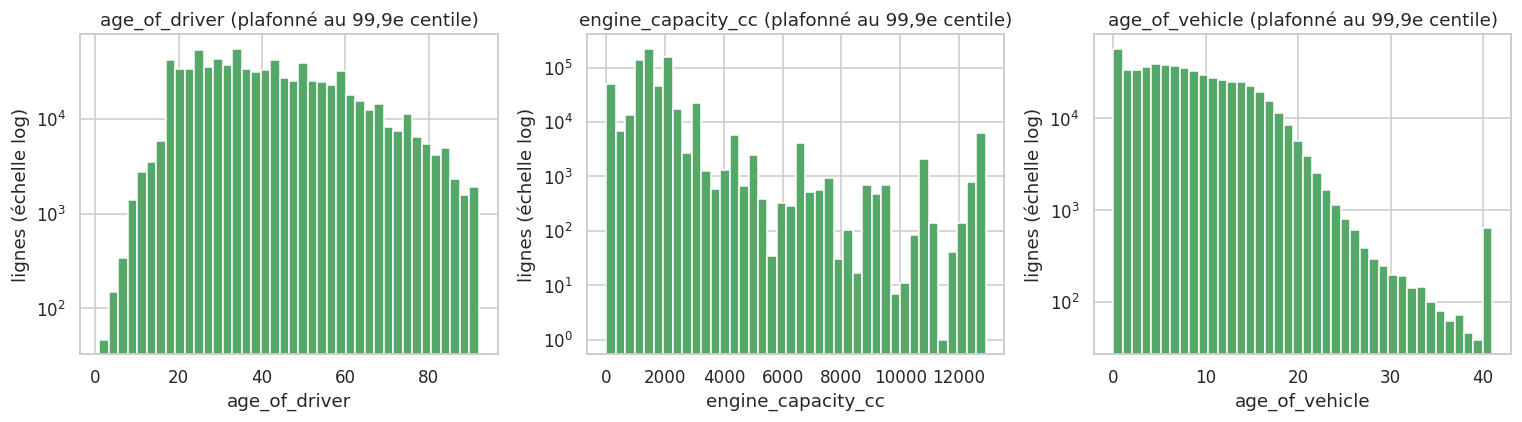

In [9]:
num_cols = ["age_of_driver", "engine_capacity_cc", "age_of_vehicle"]
valid = {c: df.loc[df[c] != -1, c] for c in num_cols}   # on exclut les -1 (manquants)

print(pd.DataFrame(valid).describe(percentiles=[.5, .9, .99, .999]).round(1))
print()
print("Conducteurs de moins de 17 ans       :", ((valid["age_of_driver"] < 17)).sum())
print("Conducteurs de plus de 100 ans       :", (valid["age_of_driver"] > 100).sum())
print("Cylindrée > 8 000 cc                 :", (valid["engine_capacity_cc"] > 8000).sum())
print("Cylindrée entre 1 et 49 cc           :", ((valid["engine_capacity_cc"] > 0) & (valid["engine_capacity_cc"] < 50)).sum())
print("Véhicules de plus de 30 ans          :", (valid["age_of_vehicle"] > 30).sum())
print("Véhicules de plus de 50 ans          :", (valid["age_of_vehicle"] > 50).sum())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, c in zip(axes, num_cols):
    ax.hist(valid[c].clip(upper=valid[c].quantile(.999)), bins=40, color="#55A868")
    ax.set_yscale("log")
    ax.set_title(f"{c} (plafonné au 99,9e centile)")
    ax.set_xlabel(c); ax.set_ylabel("lignes (échelle log)")
plt.tight_layout(); plt.show()

In [10]:
# Cylindrée selon le type de motorisation : y a-t-il des cylindrées incohérentes ?
(df[df["engine_capacity_cc"] > 0]
   .groupby("vehicle_type")["engine_capacity_cc"]
   .agg(["size", "median", "max"])
   .sort_values("size", ascending=False).head(8))

,size,median,max
vehicle_type,,,
9,536027,1582.0,15000
19,50338,1995.0,29980
3,41524,125.0,2298
5,21535,865.0,7817
8,12343,1798.0,6592
11,11809,5132.0,18146
21,10742,12740.0,16400
4,8369,250.0,7817


**Lecture :** Sur les valeurs renseignées (hors `-1`) : l'âge du conducteur va de 1 à 105 ans (médiane 39 ans, 99,9ᵉ centile 92 ans, 4 conducteurs de plus de 100 ans) ; 13 962 conducteurs ont moins de 17 ans, ce qui est plausible (vélos, mobylettes). La cylindrée a une médiane de 1 560 cc et monte jusqu'à 48 000 cc : les 11 444 valeurs > 8 000 cc correspondent aux poids lourds et bus (médiane 12 740 cc pour les poids lourds), donc ne sont **pas** des erreurs, alors que 1 639 valeurs entre 1 et 49 cc sont suspectes et à examiner. L'âge du véhicule a une médiane de 8 ans mais un maximum de 123 ans (1 525 véhicules de plus de 30 ans, 262 de plus de 50 ans). Le 99,9ᵉ centile (92 ans, 12 902 cc, 41 ans) est le seuil de plafonnement retenu dans le nettoyage.

## 6. La cible : la gravité

La table Vehicle n'a pas de gravité. On la récupère dans la table Collision par `collision_index` (relation plusieurs véhicules → une collision).

In [11]:
COLL_PATH = find_file("*collision*")
HAS_COLL = COLL_PATH is not None
if HAS_COLL:
    coll_cols = ["collision_index", "collision_severity", "collision_injury_based",
                 "collision_adjusted_severity_serious", "number_of_vehicles",
                 "date", "time", "speed_limit", "urban_or_rural_area", "light_conditions"]
    coll = read_raw(COLL_PATH, usecols=coll_cols)
    print("Table Collision :", COLL_PATH, f"({len(coll):,} lignes)")
    dfm = df.merge(coll, on="collision_index", how="left", validate="m:1", indicator=True)
    print("Véhicules rattachés à une collision :", f"{(dfm['_merge'] == 'both').mean()*100:.2f} %")
    dfm = dfm.drop(columns="_merge")
    dfm["grave_ou_mortelle"] = (dfm["collision_severity"] <= 2).astype(int)
else:
    print("Table Collision absente de data_brut/ : les sections 6 à 11 qui utilisent la gravité sont ignorées.")

Table Collision absente de data_brut/ : les sections 6 à 11 qui utilisent la gravité sont ignorées.


In [12]:
if HAS_COLL:
    sev_labels = {1: "Mortelle", 2: "Grave", 3: "Légère"}
    order = ["Légère", "Grave", "Mortelle"]
    # Niveau véhicule (une collision à 5 véhicules compte 5 fois) vs niveau collision
    sev_veh = dfm["collision_severity"].map(sev_labels).value_counts(normalize=True).reindex(order) * 100
    sev_col = coll["collision_severity"].map(sev_labels).value_counts(normalize=True).reindex(order) * 100
    cmp_ = pd.DataFrame({"niveau véhicule (%)": sev_veh, "niveau collision (%)": sev_col}).round(1)
    display(cmp_)
    cmp_.plot.bar(rot=0, figsize=(6, 4), color=["#4C72B0", "#DD8452"])
    plt.title("Répartition de la gravité : véhicules vs collisions"); plt.ylabel("%")
    plt.tight_layout(); plt.show()

**Lecture :** *(à compléter après exécution avec la table Collision dans `data_brut/`.)* À vérifier : une collision à plusieurs véhicules est comptée plusieurs fois au niveau véhicule, donc la répartition de la gravité peut différer de celle de la table Collision (75,8 % légères, 22,7 % graves, 1,5 % mortelles). Pour modéliser la gravité d'une collision, il faudra **agréger les véhicules au niveau collision** (une ligne par `collision_index`) plutôt que de joindre ligne à ligne.

## 7. Biais : conducteurs non identifiés et changement de saisie

In [13]:
# Sexe du conducteur : 3 = "non renseigné/non retrouvé" ; âge -1 : même population ?
ct = pd.crosstab(df["sex_of_driver"].map({1: "Homme", 2: "Femme", 3: "Non renseigné (3)", -1: "Manquant (-1)"}),
                 np.where(df["age_of_driver"] == -1, "âge = -1", "âge connu"))
display(ct)
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

# Évolution par année du % de conducteurs "sexe = 3" et "âge = -1"
drv = pd.DataFrame({
    "sexe = 3 (%)": df.groupby("collision_year")["sex_of_driver"].apply(lambda s: (s == 3).mean() * 100),
    "âge = -1 (%)": df.groupby("collision_year")["age_of_driver"].apply(lambda s: (s == -1).mean() * 100),
    "véhicule hors voiture (%)": df.groupby("collision_year")["vehicle_type"].apply(lambda s: (s != 9).mean() * 100),
})
display(drv.round(1))

col_0,âge = -1,âge connu
sex_of_driver,,
Femme,8639,230485
Homme,28154,547617
Manquant (-1),7278,567
Non renseigné (3),98169,16356


col_0,âge = -1,âge connu
sex_of_driver,,
Femme,3.6,96.4
Homme,4.9,95.1
Manquant (-1),92.8,7.2
Non renseigné (3),85.7,14.3


,sexe = 3 (%),âge = -1 (%),véhicule hors voiture (%)
collision_year,,,
2021,12.1,14.0,32.3
2022,12.7,15.1,31.7
2023,13.5,15.8,31.4
2024,11.8,15.6,31.5
2025,11.0,15.4,33.0


In [14]:
if HAS_COLL:
    # Les conducteurs non identifiés sont-ils plus souvent dans des collisions graves ?
    g = dfm.assign(statut_conducteur=np.where(dfm["sex_of_driver"] == 3, "non renseigné (sexe=3)", "identifié"))
    print("% graves ou mortelles selon le statut du conducteur :")
    print((g.groupby("statut_conducteur")["grave_ou_mortelle"].mean() * 100).round(1))
    print()
    print("% graves selon collision_injury_based (mode de saisie de la collision) :")
    print((dfm.groupby("collision_injury_based")["collision_severity"].apply(lambda s: (s == 2).mean()) * 100).round(1))

**Lecture :** Les conducteurs « non identifiés » forment un groupe à part : 114 525 lignes ont `sex_of_driver = 3` (12,2 %), et 86 % d'entre elles ont aussi un âge manquant ; à l'inverse, 69 % des âges manquants (98 169 sur 142 240) ont `sexe = 3`. Ce groupe est stable d'une année à l'autre (11 à 13,5 % selon l'année), de même que la part de véhicules autres que voitures (~32 %). Hypothèse (non vérifiée ici) : conducteurs non retrouvés, par exemple en cas de délit de fuite, ce qui rendrait ces manquants **non aléatoires** et probablement liés à la gravité. À vérifier avec la jointure Collision (cellule ci-dessus). Conséquence : ne pas imputer l'âge ou le sexe de ces lignes, mais les garder comme catégorie « non identifié ».

## 8. Analyse temporelle

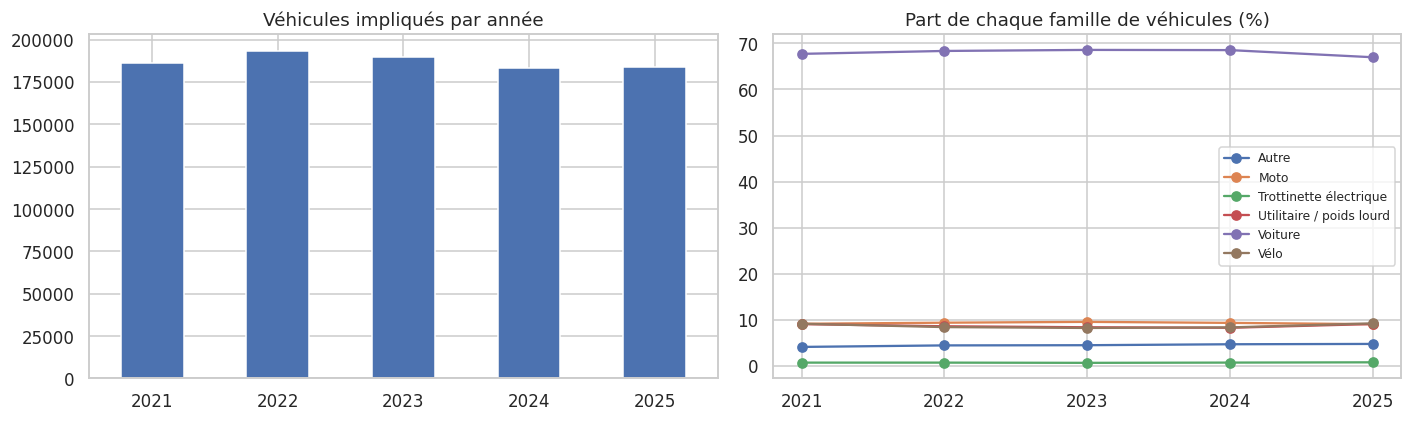

famille,Autre,Moto,Trottinette électrique,Utilitaire / poids lourd,Voiture,Vélo
collision_year,,,,,,
2021,4.1,9.2,0.7,9.1,67.7,9.2
2022,4.5,9.4,0.7,8.6,68.3,8.4
2023,4.5,9.6,0.7,8.4,68.6,8.3
2024,4.7,9.4,0.7,8.3,68.5,8.4
2025,4.8,9.1,0.8,9.1,67.0,9.3


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("collision_year").size().plot.bar(ax=axes[0], color="#4C72B0", rot=0)
axes[0].set_title("Véhicules impliqués par année"); axes[0].set_xlabel("")

share = (df.assign(famille=df["vehicle_type"].map(
            lambda t: "Voiture" if t == 9 else "Vélo" if t == 1 else
                      "Moto" if t in (2, 3, 4, 5, 23, 97) else
                      "Utilitaire / poids lourd" if t in (19, 20, 21, 98) else
                      "Trottinette électrique" if t == 33 else "Autre"))
           .groupby(["collision_year", "famille"]).size().unstack()
           .pipe(lambda t: t.div(t.sum(axis=1), axis=0) * 100))
share.plot(ax=axes[1], marker="o")
axes[1].set_title("Part de chaque famille de véhicules (%)"); axes[1].set_xlabel("")
axes[1].set_xticks(range(2021, 2026)); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(share.round(1))

In [16]:
if HAS_COLL:
    dfm["date_dt"] = pd.to_datetime(dfm["date"], format="%d/%m/%Y")
    dfm["hour"] = dfm["time"].str[:2].astype(int)
    dfm["month"] = dfm["date_dt"].dt.month
    dfm["famille"] = dfm["vehicle_type"].map(
        lambda t: "Voiture" if t == 9 else "Vélo" if t == 1 else
                  "Moto" if t in (2, 3, 4, 5, 23, 97) else "Autre")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for fam in ["Voiture", "Vélo", "Moto"]:
        s = dfm[dfm.famille == fam]
        m = s.groupby("month").size(); m = m / m.sum() * 100
        h = s.groupby("hour").size(); h = h / h.sum() * 100
        axes[0].plot(m.index, m.values, marker="o", label=fam)
        axes[1].plot(h.index, h.values, marker="o", label=fam)
    axes[0].set_title("Profil mensuel (% des véhicules de la famille)"); axes[0].set_xlabel("mois")
    axes[1].set_title("Profil horaire (% des véhicules de la famille)"); axes[1].set_xlabel("heure")
    for a in axes: a.legend(fontsize=8); a.set_ylabel("%")
    plt.tight_layout(); plt.show()

**Lecture :** Volume stable : 183 500 à 193 500 véhicules par an (186 443 en 2021, 193 545 en 2022, 189 815 en 2023, 183 514 en 2024, 183 948 en 2025), en cohérence avec les ~101-106 k collisions par an. La composition du parc est très stable : voitures 67 à 68,6 %, vélos 8,3 à 9,3 %, motos 9,1 à 9,6 %, utilitaires et poids lourds 8,3 à 9,1 %, trottinettes électriques ~0,7-0,8 %. *(Profils mensuels et horaires par famille : à interpréter après exécution avec la table Collision.)*

## 9. Gravité selon les caractéristiques du véhicule et du conducteur

In [17]:
VT = {1: "Vélo", 2: "Moto ≤50cc", 3: "Moto ≤125cc", 4: "Moto 125-500cc", 5: "Moto >500cc",
      8: "Taxi/VTC", 9: "Voiture", 11: "Bus/car", 19: "Utilitaire ≤3,5t", 21: "Poids lourd >7,5t",
      33: "Trottinette él.", 90: "Autre"}
if HAS_COLL:
    print(f"Taux global de véhicules dans une collision grave ou mortelle : {dfm['grave_ou_mortelle'].mean()*100:.1f} %")

    def rate_by(col, exclude=(), labels=None, min_n=1000):
        d = dfm[~dfm[col].isin(exclude)]
        r = d.groupby(col)["grave_ou_mortelle"].agg(["mean", "size"])
        r = r[r["size"] >= min_n].copy()
        r["mean"] *= 100
        if labels:
            r = r[r.index.isin(labels)]
            r.index = [labels[i] for i in r.index]
        return r

    AGE_BAND = {1: "0-5", 2: "6-10", 3: "11-15", 4: "16-20", 5: "21-25", 6: "26-35",
                7: "36-45", 8: "46-55", 9: "56-65", 10: "66-75", 11: "75+"}
    IMPACT = {0: "Aucun", 1: "Avant", 2: "Arrière", 3: "Côté gauche", 4: "Côté droit"}
    panels = [("vehicle_type", (-1, 99), VT, "Type de véhicule"),
              ("age_band_of_driver", (-1,), AGE_BAND, "Âge du conducteur"),
              ("sex_of_driver", (-1,), {1: "Homme", 2: "Femme", 3: "Non renseigné"}, "Sexe du conducteur"),
              ("first_point_of_impact", (-1, 9), IMPACT, "Premier point d'impact")]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, (col, exc, lab, title) in zip(axes.ravel(), panels):
        r = rate_by(col, exc, lab)
        ax.bar(r.index.astype(str), r["mean"], color="#C44E52")
        ax.axhline(dfm["grave_ou_mortelle"].mean() * 100, color="grey", ls="--", lw=1)
        ax.set_title(f"% graves ou mortelles - {title}"); ax.set_ylabel("%")
        plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    plt.tight_layout(); plt.show()

In [18]:
if HAS_COLL:
    # Âge du véhicule (hors 2025 où il est entièrement manquant) et cylindrée
    d = dfm[(dfm["age_of_vehicle"] >= 0)]
    d = d.assign(tranche=pd.cut(d["age_of_vehicle"], [-1, 2, 5, 10, 15, 200],
                                labels=["0-2 ans", "3-5", "6-10", "11-15", ">15"]))
    print("% graves ou mortelles selon l'âge du véhicule :")
    print((d.groupby("tranche", observed=True)["grave_ou_mortelle"].mean() * 100).round(1))

**Lecture :** *(à compléter après exécution avec la table Collision.)* Points à regarder : l'écart de gravité entre vélos, motos et voitures (la gravité de la collision est celle de **la collision entière**, pas du véhicule : il faudra la relier au véhicule le plus vulnérable), l'effet de l'âge du conducteur (jeunes et seniors) et du premier point d'impact. Pour l'âge du véhicule, attention : 2025 est entièrement manquant (section 4), la cellule le retire.

## 10. Profil socio-géographique du conducteur

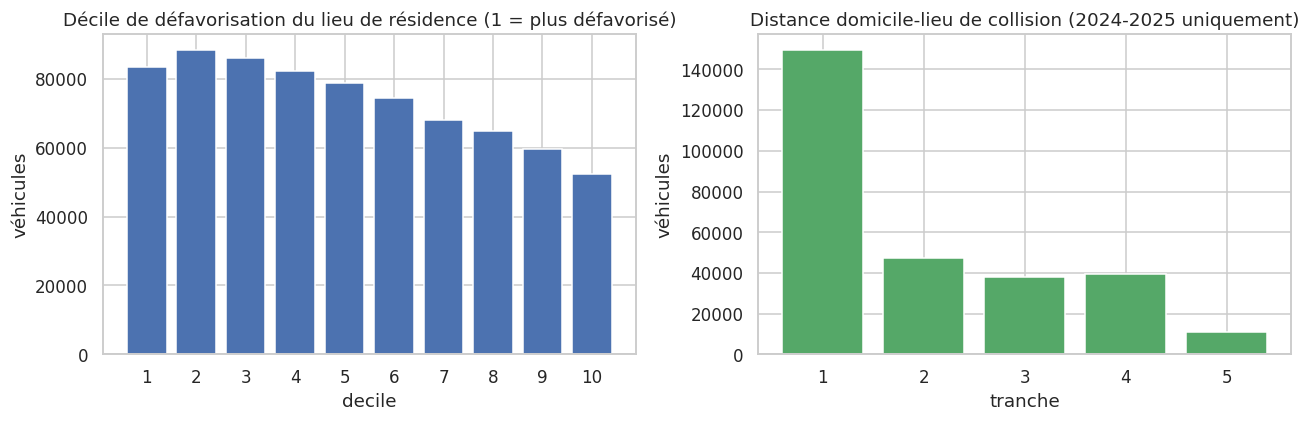

lsoa_of_driver : valeurs distinctes = 36673 | % de -1 = 24.3
driver_imd_decile = -1 : 21.3 %
lsoa = -1 ET imd = -1 : 21.3 %
Valeurs distinctes de generic_make_model : 958


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
imd = df.loc[df["driver_imd_decile"] != -1, "driver_imd_decile"].value_counts().sort_index()
axes[0].bar(imd.index.astype(str), imd.values, color="#4C72B0")
axes[0].set_title("Décile de défavorisation du lieu de résidence (1 = plus défavorisé)")
axes[0].set_xlabel("decile"); axes[0].set_ylabel("véhicules")

dist = df.loc[(df["driver_distance_banding"] != -1), "driver_distance_banding"].value_counts().sort_index()
axes[1].bar(dist.index.astype(str), dist.values, color="#55A868")
axes[1].set_title("Distance domicile-lieu de collision (2024-2025 uniquement)")
axes[1].set_xlabel("tranche"); axes[1].set_ylabel("véhicules")
plt.tight_layout(); plt.show()

print("lsoa_of_driver : valeurs distinctes =", df["lsoa_of_driver"].nunique(), "| % de -1 =", round(pct_minus1(df["lsoa_of_driver"]), 1))
print("driver_imd_decile = -1 :", round(pct_minus1(df["driver_imd_decile"]), 1), "%")
print("lsoa = -1 ET imd = -1 :", round(((df["lsoa_of_driver"] == "-1") & (df["driver_imd_decile"] == -1)).mean() * 100, 1), "%")
print("Valeurs distinctes de generic_make_model :", df["generic_make_model"].nunique())

In [20]:
if HAS_COLL:
    r = (dfm[dfm["driver_imd_decile"] != -1].groupby("driver_imd_decile")["grave_ou_mortelle"].mean() * 100)
    ax = r.plot.bar(color="#C44E52", figsize=(6, 3.5), rot=0)
    ax.axhline(dfm["grave_ou_mortelle"].mean() * 100, color="grey", ls="--", lw=1)
    ax.set_title("% graves ou mortelles selon le décile du conducteur"); ax.set_ylabel("%"); ax.set_xlabel("décile")
    plt.tight_layout(); plt.show()

**Lecture :** Le décile de défavorisation du conducteur (1 = lieu de résidence le plus défavorisé) n'est pas uniforme : parmi les valeurs renseignées, les déciles 1 à 4 sont les plus représentés (environ 11 % pour le décile 1 contre ~7 % pour le décile 10), sans qu'on puisse conclure à une surexposition sans données de trafic ou de population. `driver_distance_banding` n'existe qu'à partir de 2024 et la tranche 1 regroupe à elle seule plus de la moitié des valeurs renseignées. `lsoa_of_driver` a 36 673 modalités : inutilisable telle quelle, on gardera plutôt le décile. `generic_make_model` a 958 modalités et 24 % de `-1` : à regrouper ou à écarter.

## 11. Liens avec la gravité (V de Cramér)

In [21]:
def cramers_v(x, y):
    """Association entre deux variables catégorielles (0 = aucune, 1 = totale), corrigée du biais."""
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    phi2c = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2c / min(kc - 1, rc - 1))

if HAS_COLL:
    work = dfm.copy()
    work["engine_band"] = pd.cut(work["engine_capacity_cc"].where(work["engine_capacity_cc"] > 0),
                                 [0, 125, 500, 1000, 1600, 2000, 3000, 100000]).astype(object)
    work["vehicle_age_band"] = pd.cut(work["age_of_vehicle"].where(work["age_of_vehicle"] >= 0),
                                      [-1, 2, 5, 10, 15, 200]).astype(object)
    candidates = {   # variable : codes à exclure (manquants)
        "vehicle_type": [-1, 99], "age_band_of_driver": [-1], "sex_of_driver": [-1],
        "first_point_of_impact": [-1, 9], "vehicle_manoeuvre": [-1, 99],
        "junction_location": [-1, 9], "skidding_and_overturning": [-1, 9],
        "vehicle_leaving_carriageway": [-1, 9], "hit_object_in_carriageway": [-1, 99],
        "hit_object_off_carriageway": [-1, 99], "journey_purpose_of_driver": [-1, 9],
        "propulsion_code": [-1], "driver_imd_decile": [-1], "towing_and_articulation": [-1, 9],
        "vehicle_direction_from": [-1, 9], "escooter_flag": [], "collision_year": [],
        "engine_band": [], "vehicle_age_band": [],
    }
    res = {}
    for c, bad in candidates.items():
        d = work[~work[c].isin(bad)].dropna(subset=[c])
        res[c] = cramers_v(d[c], d["collision_severity"])
    res = pd.Series(res).sort_values()

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(res.index, res.values, color="#8172B3")
    ax.set_xlabel("V de Cramér avec collision_severity")
    ax.set_title("Variables Vehicle les plus liées à la gravité")
    plt.tight_layout(); plt.show()

In [22]:
if HAS_COLL:
    # Pourquoi la variable la plus liée l'est-elle ? (lecture à faire après le graphique)
    top_var = res.index[-1]
    print("Variable la plus liée :", top_var)
    display((pd.crosstab(work[top_var], work["collision_severity"], normalize="index")
             .rename(columns=sev_labels) * 100).round(1).head(15))

**Lecture :** *(à compléter après exécution avec la table Collision.)* Rappel de la méthode : le V de Cramér mesure une association, pas une causalité. Comme dans l'EDA Collision, on s'attend à des associations faibles ; regarder en particulier le type de véhicule, l'âge du conducteur et le point d'impact, et se méfier des variables dont le lien vient d'un effet de sélection (conducteur non identifié, colonnes absentes certaines années).

## 12. Synthèse : constats → décisions de nettoyage


| Constat (EDA) | Décision dans `clean_vehicle.py` |
|---|---|
| `collision_index` répété (un véhicule par ligne), clé réelle = (`collision_index`, `vehicle_reference`) | Garder les deux colonnes comme clé ; supprimer `collision_ref_no` |
| `vehicle_reference` irrégulier (jusqu'à 992, 577 lignes > nb de véhicules) | Ne pas l'utiliser comme compteur ; recompter les véhicules par collision |
| Manquants cachés sous `-1`, `9`, `99` selon la colonne ; `9` = voiture / manoeuvre / tranche d'âge / décile | Conversion en NaN **colonne par colonne** (ne jamais toucher `vehicle_type = 9`) |
| `-1` = non applicable pour les vélos et les véhicules électriques (`propulsion_code`, `age_of_vehicle`, `engine_capacity_cc`) | Distinguer « non applicable » de « manquant » (valeur 0 ou NaN + indicateur) |
| Anciennes colonnes `*_historic` vides en 2024-2025, remplacées par des colonnes complètes | Suppression des anciennes colonnes (pas de table de correspondance) |
| `age_of_vehicle` à 100 % de `-1` en 2025 ; `driver_distance_banding` à 100 % de `-1` avant 2024 (69,5 % au total) | Ne pas imputer ; supprimer `driver_distance_banding` ; traiter `age_of_vehicle` avec prudence (indicateur ou exclusion de 2025 pour les analyses) |
| `sex_of_driver = 3` et `age_of_driver = -1` sur les mêmes lignes (conducteur non identifié, ~12-15 %) | Pas d'imputation ; catégorie « non identifié » + indicateur `driver_not_identified` |
| `age_band_of_driver` redondant avec `age_of_driver` (mêmes lignes à -1) | Garder l'âge exact, dériver les tranches si besoin |
| Valeurs extrêmes : âge véhicule jusqu'à 123 ans, cylindrée jusqu'à 48 000 cc, âge conducteur 105 ans | Colonnes `*_capped` au 99,9ᵉ centile ; colonnes d'origine conservées ; cylindrées de 1 à 49 cc à examiner |
| `lsoa_of_driver` : 36 673 modalités, 24 % de `-1` ; `driver_imd_decile` dérivé du LSOA | Supprimer `lsoa_of_driver`, garder le décile (NaN si -1) |
| `generic_make_model` : 958 modalités, 24 % de `-1` | Regrouper les modèles rares ou supprimer |
| Pas de gravité dans cette table ; une collision = plusieurs véhicules | Agréger au niveau collision (nb de voitures, motos, vélos, âge min/moyen, présence d'un conducteur non identifié...) avant de joindre à Collision |
| Cible déséquilibrée, saisie qui change (cf. EDA Collision) | À traiter au moment de la modélisation |

**Limites de cette EDA :** seule la table Vehicle est analysée (la gravité vient d'une jointure avec Collision) ; une ligne est un véhicule, pas une collision ; seules les collisions corporelles déclarées à la police sont recensées ; les interprétations des codes `9`/`99` sont à confirmer avec le guide DfT ; une association (V de Cramér) n'est pas une causalité.